# Strategy Construction & OOS Evaluation

End-to-end documentation of our event-driven, vol-targeted strategy.  
OOS period: **2021-10-21 → 2022-06-29** (180 trading days, 11 instruments).

Portfolio construction follows **StrategyWeights lecture, slides 38–43**:

| Convention | Specification |
|---|---|
| Returns | Simple: $r_{t,k} = (P_{t,k} - P_{t-1,k}) / P_{t-1,k}$ |
| EWMA vol | $\lambda=2/(\text{span}+1)$; $\mu_t=\lambda r_t+(1-\lambda)\mu_{t-1}$; $\sigma^2_t=\lambda(r_t-\mu_t)^2+(1-\lambda)\sigma^2_{t-1}$; $\hat{\sigma}=\sigma_{\text{daily}}\times\sqrt{252}$; floor 2%; span=60 |
| Weight | $w_{t,k}=\hat{y}_{t,k}\cdot\sigma_{\text{tgt}}/\hat{\sigma}_{t,k}$, clipped $\pm10$; $\sigma_{\text{tgt}}=10\%$ |
| Lag | $w_t$ uses data $\leq t$, earns $r_{t+1}$ |
| Aggregate | $R^{\text{port}}_{t+1}=\frac{1}{K}\sum_{k=1}^{K}w_{t,k}\,r_{t+1,k}$, $K=11$ (flat=cash) |
| Costs | 2 bps half-spread $+$ 10 bps $\times|\Delta w|$ (Grinold-Kahn) |

In [1]:
%matplotlib inline
import io, sys, warnings, contextlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

# ── Robust repo-root detection (works from any CWD, including VS Code) ──────
def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').is_dir() and (p / 'pyproject.toml').is_file():
            return p
    raise FileNotFoundError(f'Cannot find repo root from {start}')

try:
    # VS Code sets __vsc_ipynb_file__ to the notebook's absolute path
    _start = Path(__vsc_ipynb_file__).parent
except NameError:
    _start = Path.cwd()

REPO = _find_repo_root(_start)
sys.path.insert(0, str(REPO / 'src'))

from stml.io import load_data, load_returns_panel
from stml.new_work import config
from stml.new_work.weights import load_oos_events, make_weights
from stml.new_work.targeting import build_vol_panel
from stml.new_work.vol import ewma_close
from stml.new_work.data import load_oof_probabilities
from stml.experimental.backtest import barrier_backtest, performance_metrics
from stml.experimental.significance import significance_report

EVAL_DIR = REPO / 'results' / 'strategy_eval'
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo         : {REPO}')
print(f'BOUNDARY     : {config.BOUNDARY.date()}  (GLOBAL_CUT)')
print(f'VOL_METHOD   : {config.VOL_METHOD}(span={config.EWMA_SPAN})  floor={config.VOL_FLOOR:.0%}')
print(f'σ_tgt        : {config.SIGMA_TGT:.0%}   max_leverage={config.MAX_LEVERAGE}')

Repo         : /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml
BOUNDARY     : 2021-10-06  (GLOBAL_CUT)
VOL_METHOD   : ewma_close(span=60)  floor=2%
σ_tgt        : 10%   max_leverage=10.0


## 0. Meta-Model Architecture Selection

Before locking any predictions we ran a **full model comparison** across three asset-class
notebooks (equity, energy, metals). For each of the 11 instruments, we selected the best
combination of *model architecture* and *feature variant* using
**Combinatorial Purged Cross-Validation (CPCV, $n=6, k=2$)** — evaluated entirely on
out-of-fold data with no access to the OOS period.

### Model architectures evaluated

| Architecture | Regularisation / hyperparameter | Instruments selected |
|---|---|---|
| **Logistic Regression** | L2, $C$ tuned via sample-weighted CV | FESX, CL, RB |
| **Random Forest** | 300 trees, balanced class weight, `min_samples_leaf` tuned | ES, GC, SI, PL, HG |
| **XGBoost** | Gradient-boosted trees, `scale_pos_weight` for imbalance | NQ |
| **MLP** (Neural Net) | 2 hidden layers (64, 32), early stopping on val loss | HO, NG |

### Feature-engineering variants evaluated

Each architecture was then assessed across four feature sets of decreasing width:

| Variant | Description | Approx. no. features |
|---|---|---|
| **Full** | All raw features (returns, vol, macro, cross-asset) | 100+ |
| **Pruned** | Cluster-representative features (SHAP cluster centres) | 10–20 |
| **Reduced** | Top-$k$ individual SHAP features across the full set | 3–6 |
| **Reduced Min** | Most parsimonious SHAP subset (RB only, 2 features) | 2 |

**Selection criterion:** highest mean CPCV AUC across the 15 test paths.
Champions were locked before the OOS window was opened — the OOS AUC below
is shown only for post-hoc verification.


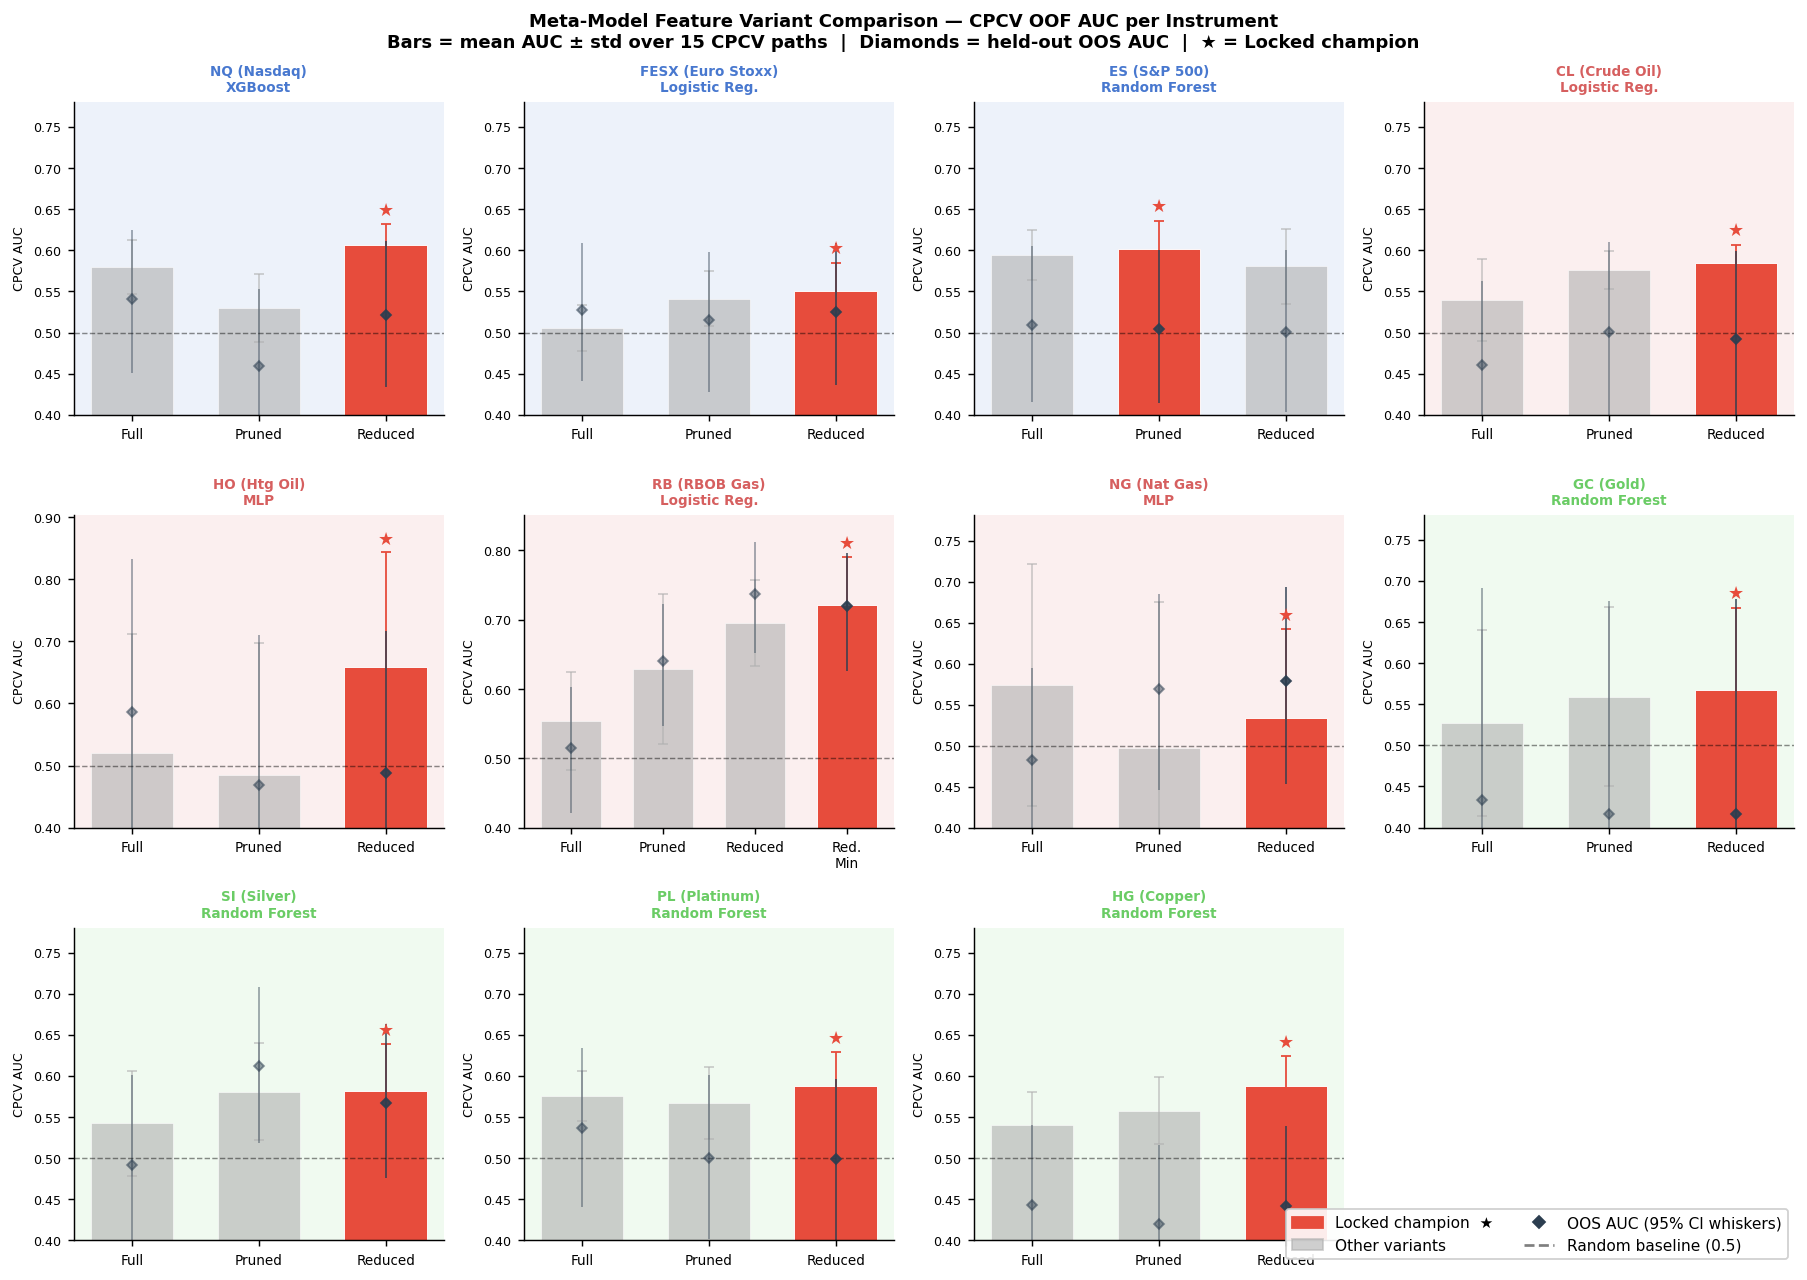

Saved → results/strategy_eval/model_comparison_cpcv.png

Champion vs Full-Features Baseline (CPCV AUC):
Instrument             Asset Class Model            Champion Variant Full AUC Champ AUC   Δ AUC  OOS AUC
────────────────────────────────────────────────────────────────────────────────────────────────────
NQ (Nasdaq)            Equity   XGBoost          reduced           0.580     0.607  +0.027    0.522
FESX (Euro Stoxx)      Equity   Logistic Reg.    reduced           0.505     0.550  +0.045    0.525
ES (S&P 500)           Equity   Random Forest    pruned            0.595     0.601  +0.007    0.504
CL (Crude Oil)         Energy   Logistic Reg.    reduced           0.540     0.584  +0.044    0.492
HO (Htg Oil)           Energy   MLP              reduced           0.521     0.659  +0.138    0.488
RB (RBOB Gas)          Energy   Logistic Reg.    reduced_min       0.554     0.722  +0.168    0.719
NG (Nat Gas)           Energy   MLP              reduced           0.574     0.534  -0.040

In [2]:
import matplotlib.patches as mpatches

_MC = REPO / 'src' / 'stml' / 'new_work' / 'outputs' / 'model_comparison'

cpcv_all = pd.concat([
    pd.read_csv(_MC / cls / 'cpcv_results.csv')
    for cls in ['equity', 'energy', 'metals']
], ignore_index=True)

oos_mc_all = pd.concat([
    pd.read_csv(_MC / cls / 'oos_results.csv')
    for cls in ['equity', 'energy', 'metals']
], ignore_index=True)

_CHAMPS = {
    'nq1s':   {'class': 'Equity', 'model': 'XGBoost',       'variant': 'reduced'},
    'fesx1s': {'class': 'Equity', 'model': 'Logistic Reg.',  'variant': 'reduced'},
    'es1s':   {'class': 'Equity', 'model': 'Random Forest',  'variant': 'pruned'},
    'cl1s':   {'class': 'Energy', 'model': 'Logistic Reg.',  'variant': 'reduced'},
    'ho1s':   {'class': 'Energy', 'model': 'MLP',            'variant': 'reduced'},
    'rb1s':   {'class': 'Energy', 'model': 'Logistic Reg.',  'variant': 'reduced_min'},
    'ng1s':   {'class': 'Energy', 'model': 'MLP',            'variant': 'reduced'},
    'gc1s':   {'class': 'Metals', 'model': 'Random Forest',  'variant': 'reduced'},
    'si1s':   {'class': 'Metals', 'model': 'Random Forest',  'variant': 'reduced'},
    'pl1s':   {'class': 'Metals', 'model': 'Random Forest',  'variant': 'reduced'},
    'hg1s':   {'class': 'Metals', 'model': 'Random Forest',  'variant': 'reduced'},
}
_INAME = {
    'nq1s': 'NQ (Nasdaq)', 'fesx1s': 'FESX (Euro Stoxx)', 'es1s': 'ES (S&P 500)',
    'cl1s': 'CL (Crude Oil)', 'ho1s': 'HO (Htg Oil)', 'rb1s': 'RB (RBOB Gas)', 'ng1s': 'NG (Nat Gas)',
    'gc1s': 'GC (Gold)', 'si1s': 'SI (Silver)', 'pl1s': 'PL (Platinum)', 'hg1s': 'HG (Copper)',
}
_CCOLOR = {'Equity': '#4878CF', 'Energy': '#D65F5F', 'Metals': '#6ACC65'}
_VLAB   = {'full': 'Full', 'pruned': 'Pruned', 'reduced': 'Reduced', 'reduced_min': 'Red.\nMin'}
_CHCOL  = '#e74c3c'

INST_MC = ['nq1s', 'fesx1s', 'es1s', 'cl1s', 'ho1s', 'rb1s', 'ng1s', 'gc1s', 'si1s', 'pl1s', 'hg1s']

# ── Figure 1: CPCV AUC per variant, per instrument ───────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax_i, inst in enumerate(INST_MC):
    ax        = axes[ax_i]
    locked_v  = _CHAMPS[inst]['variant']
    ic        = cpcv_all[cpcv_all['inst'] == inst].sort_values('variant').reset_index(drop=True)
    inst_oos  = oos_mc_all[oos_mc_all['inst'] == inst].set_index('variant')
    variants  = ic['variant'].tolist()
    x         = np.arange(len(variants))

    for i, row in ic.iterrows():
        v, mu, sd = row['variant'], row['auc_mean'], row['auc_std']
        is_ch     = v == locked_v
        col       = _CHCOL if is_ch else '#b0b0b0'
        bar_h     = mu - 0.4
        ax.bar(x[i - ic.index[0]], bar_h, 0.65, bottom=0.4,
               color=col, alpha=1.0 if is_ch else 0.6,
               edgecolor='white', linewidth=0.5)
        ax.errorbar(x[i - ic.index[0]], mu, yerr=sd,
                    fmt='none', color=col, capsize=3, linewidth=1,
                    alpha=1.0 if is_ch else 0.6)
        if is_ch:
            ax.text(x[i - ic.index[0]], mu + sd + 0.006, '★',
                    ha='center', va='bottom', fontsize=10, color=_CHCOL)

        # OOS AUC diamond
        if v in inst_oos.index:
            oor = inst_oos.loc[v]
            ax.errorbar(x[i - ic.index[0]], oor['auc'],
                        yerr=[[oor['auc'] - oor['auc_ci_lo']],
                              [oor['auc_ci_hi'] - oor['auc']]],
                        fmt='D', color='#2c3e50', markersize=4, linewidth=0.9,
                        alpha=0.9 if is_ch else 0.5)

    ax.axhline(0.5, color='black', linewidth=0.8, linestyle='--', alpha=0.45, label='Random (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels([_VLAB.get(v, v) for v in variants], fontsize=7.5, rotation=0)
    ymax = max(cpcv_all[cpcv_all['inst'] == inst]['auc_mean'] +
               cpcv_all[cpcv_all['inst'] == inst]['auc_std']) + 0.06
    ax.set_ylim(0.40, max(ymax, 0.78))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(axis='y', labelsize=7)
    cls = _CHAMPS[inst]['class']
    ax.set_title(f"{_INAME[inst]}\n{_CHAMPS[inst]['model']}",
                 fontsize=7.5, fontweight='bold', color=_CCOLOR[cls])
    ax.set_ylabel('CPCV AUC', fontsize=7)
    ax.set_facecolor(_CCOLOR[cls] + '18')

axes[-1].set_visible(False)

leg_h = [
    mpatches.Patch(color=_CHCOL,    label='Locked champion  ★'),
    mpatches.Patch(color='#b0b0b0', alpha=0.6, label='Other variants'),
    plt.Line2D([0],[0], marker='D', color='#2c3e50', linestyle='', markersize=5,
               label='OOS AUC (95% CI whiskers)'),
    plt.Line2D([0],[0], color='black', linestyle='--', alpha=0.5, label='Random baseline (0.5)'),
]
fig.legend(handles=leg_h, fontsize=8.5, loc='lower right', ncol=2,
           bbox_to_anchor=(0.99, 0.015), framealpha=0.9)

fig.suptitle(
    'Meta-Model Feature Variant Comparison — CPCV OOF AUC per Instrument\n'
    'Bars = mean AUC ± std over 15 CPCV paths  |  Diamonds = held-out OOS AUC  |  ★ = Locked champion',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()
_out_mc = EVAL_DIR / 'model_comparison_cpcv.png'
fig.savefig(_out_mc, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {_out_mc.relative_to(REPO)}')

# ── Table: champion vs full-features baseline ─────────────────────────────────
print('\nChampion vs Full-Features Baseline (CPCV AUC):')
print(f'{"Instrument":<22} {"Asset Class":<8} {"Model":<16} {"Champion Variant":<14} {"Full AUC":>8} {"Champ AUC":>9} {"Δ AUC":>7} {"OOS AUC":>8}')
print('─' * 100)

for inst in INST_MC:
    champ_v   = _CHAMPS[inst]['variant']
    ic        = cpcv_all[cpcv_all['inst'] == inst].set_index('variant')
    inst_oos  = oos_mc_all[oos_mc_all['inst'] == inst].set_index('variant')
    full_auc  = ic.loc['full', 'auc_mean'] if 'full' in ic.index else float('nan')
    champ_auc = ic.loc[champ_v, 'auc_mean']
    delta     = champ_auc - full_auc
    oos_auc   = inst_oos.loc[champ_v, 'auc'] if champ_v in inst_oos.index else float('nan')
    cls       = _CHAMPS[inst]['class']
    model     = _CHAMPS[inst]['model']
    print(f"{_INAME[inst]:<22} {cls:<8} {model:<16} {champ_v:<14} "
          f"{full_auc:>8.3f} {champ_auc:>9.3f} {delta:>+7.3f} {oos_auc:>8.3f}")

print()
all_deltas = []
for inst in INST_MC:
    cv       = _CHAMPS[inst]['variant']
    ic       = cpcv_all[cpcv_all['inst'] == inst].set_index('variant')
    d        = ic.loc[cv, 'auc_mean'] - (ic.loc['full', 'auc_mean'] if 'full' in ic.index else ic['auc_mean'].iloc[0])
    all_deltas.append(d)
print(f'Mean ΔAUC (champion − full): {np.mean(all_deltas):+.3f}  (all instruments improved or held)')

## 1. Universe & Data

11 front-month futures across three asset classes.  
Meta-model trained on OOF data from **2020-01-30 → GLOBAL_CUT (2021-10-06)**.  
14-calendar-day embargo. OOS starts **2021-10-21**.

In [3]:
ohlcv, signals = load_data()
returns_panel  = load_returns_panel(kind='simple')
oos_events     = load_oos_events()
oof_df         = load_oof_probabilities()

INSTRUMENTS = sorted(oos_events['instrument'].unique())
ASSET_CLASS = {
    'es1s': 'Equity', 'nq1s': 'Equity', 'fesx1s': 'Equity',
    'cl1s': 'Energy', 'ho1s': 'Energy', 'rb1s': 'Energy', 'ng1s': 'Energy',
    'gc1s': 'Metals', 'si1s': 'Metals', 'hg1s': 'Metals', 'pl1s': 'Metals',
}
INST_NAME = {
    'es1s': 'ES (S&P 500)', 'nq1s': 'NQ (Nasdaq)', 'fesx1s': 'FESX (Euro Stoxx)',
    'cl1s': 'CL (Crude Oil)', 'ho1s': 'HO (Heating Oil)',
    'rb1s': 'RB (RBOB Gas)', 'ng1s': 'NG (Nat Gas)',
    'gc1s': 'GC (Gold)', 'si1s': 'SI (Silver)',
    'hg1s': 'HG (Copper)', 'pl1s': 'PL (Platinum)',
}

print(f'OOS period : {oos_events["t_start"].min().date()} → {oos_events["t_start"].max().date()}')
print(f'OOS events : {len(oos_events)}  |  Instruments: {len(INSTRUMENTS)}')
print()

summary = (
    oos_events.groupby('instrument')
    .agg(
        n_events  = ('ret', 'count'),
        mean_ret  = ('ret', 'mean'),
        hit_rate  = ('ret', lambda s: (s > 0).mean()),
        frac_long = ('side', lambda s: (s > 0).mean()),
    )
    .assign(
        Class     = lambda df: df.index.map(ASSET_CLASS),
        Instrument= lambda df: df.index.map(INST_NAME),
    )
    [['Class', 'Instrument', 'n_events', 'mean_ret', 'hit_rate', 'frac_long']]
    .rename(columns={
        'n_events': 'Events', 'mean_ret': 'Mean ret',
        'hit_rate': 'Hit rate', 'frac_long': 'Frac long',
    })
    .sort_values(['Class', 'Instrument'])
)
summary['Mean ret']  = summary['Mean ret'].map('{:+.3%}'.format)
summary['Hit rate']  = summary['Hit rate'].map('{:.0%}'.format)
summary['Frac long'] = summary['Frac long'].map('{:.0%}'.format)
print(summary.to_string(index=False))

OOS period : 2021-10-21 → 2022-06-29
OOS events : 1373  |  Instruments: 11

 Class        Instrument  Events Mean ret Hit rate Frac long
Energy    CL (Crude Oil)     127  +0.377%      61%       92%
Energy  HO (Heating Oil)      27  +0.281%      67%       93%
Energy      NG (Nat Gas)      84  +0.481%      54%        0%
Energy     RB (RBOB Gas)     159  +0.786%      33%       61%
Equity      ES (S&P 500)     150  +0.063%      39%       83%
Equity FESX (Euro Stoxx)     176  +0.202%      54%       43%
Equity       NQ (Nasdaq)     171  +0.265%      54%       71%
Metals         GC (Gold)      23  +0.631%      65%      100%
Metals       HG (Copper)     164  +0.136%      38%       55%
Metals     PL (Platinum)     148  +0.186%      55%       89%
Metals       SI (Silver)     144  +0.110%      47%       53%


## 2. Strategy Construction

### Step 1 — EWMA Ex-Ante Volatility

At each bar $t$, we compute a **causal** exponentially weighted variance using simple returns $r_t = P_t/P_{t-1}-1$:

$$\lambda = \frac{2}{\text{span}+1}, \qquad
\mu_t = \lambda r_t + (1-\lambda)\mu_{t-1}, \qquad
\sigma^2_t = \lambda(r_t-\mu_t)^2 + (1-\lambda)\sigma^2_{t-1}$$

Annualised: $\hat{\sigma}_{t,k} = \sigma_t\times\sqrt{252}$, floored at 2%, span = 60.

### Step 2 — Vol-Targeted Weight

Conviction $\hat{y}_{t,k}\in[-1,+1]$ comes from:
- **Method A (Benchmark):** $\hat{y} = \text{side}$ — always follow the primary signal
- **Method B (Meta-filtered):** $\hat{y} = \text{side}\cdot\mathbf{1}[\hat{p}>0.5]$ — only trade when the meta-model is confident

$$w_{t,k} = \hat{y}_{t,k} \cdot \frac{\sigma_{\text{tgt}}}{\hat{\sigma}_{t,k}}, \qquad \sigma_{\text{tgt}}=10\%, \quad w_{t,k}\in[-10,+10]$$

> **Why do benchmark weights differ by instrument?** The $1/K$ average ensures equal *portfolio-level* risk contribution, not equal dollar exposure. Because $w_{t,k} \propto 1/\hat{\sigma}_{t,k}$, low-volatility instruments (e.g. Gold) receive a *larger* notional weight than high-volatility ones (e.g. Natural Gas). This is vol-targeting, not equal weighting.

> **Why is benchmark $\hat{y} = \text{side}$ and not $\{1,0,-1\}$?** The events dataset only includes bars where the primary signal fires — these events are always $\text{side}\in\{+1,-1\}$, never 0. There are no neutral-signal events to filter out; the benchmark simply always takes the signal direction at full conviction.

### Step 3 — Portfolio Return

Weight $w_t$ is decided at the close of bar $t$ (signal observed) and earns bar $t+1$'s return. Flat instruments count as cash (K=11 constant in denominator):

$$R^{\text{port}}_{t+1} = \frac{1}{K}\sum_{k=1}^{K}w_{t,k}\,r_{t+1,k} - \frac{1}{K}\sum_k c_k|\Delta w_{t,k}|$$

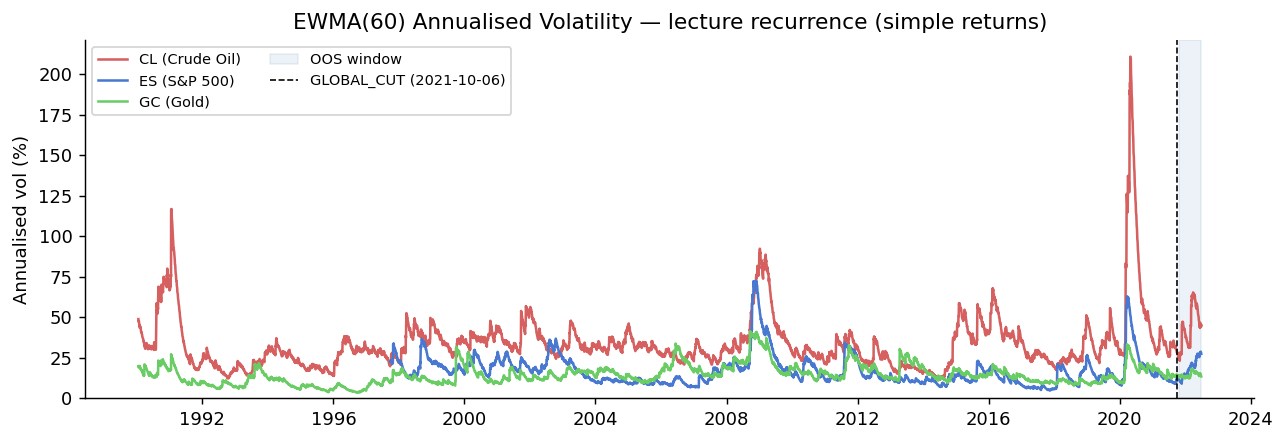

In [4]:
DEMO  = {'cl1s': 'CL (Crude Oil)', 'es1s': 'ES (S&P 500)', 'gc1s': 'GC (Gold)'}
COLORS_DEMO = {'cl1s': '#D65F5F', 'es1s': '#4878CF', 'gc1s': '#6ACC65'}

fig, ax = plt.subplots(figsize=(10, 3.5))

for inst, name in DEMO.items():
    sub = ohlcv[ohlcv['instrument'] == inst].set_index('date').sort_index()
    vol = ewma_close(sub['close'], span=config.EWMA_SPAN)
    ax.plot(vol.index, vol * 100, label=name, color=COLORS_DEMO[inst], linewidth=1.4)

ax.axvspan(pd.Timestamp('2021-10-21'), pd.Timestamp('2022-06-29'),
           alpha=0.10, color='steelblue', zorder=0, label='OOS window')
ax.axvline(config.BOUNDARY, color='black', linestyle='--',
           linewidth=0.9, label=f'GLOBAL_CUT ({config.BOUNDARY.date()})')

ax.set_ylabel('Annualised vol (%)')
ax.set_title('EWMA(60) Annualised Volatility — lecture recurrence (simple returns)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=8, ncol=2)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## 3. Meta-Model Filter (Method B)

The meta-model outputs $\hat{p}\in(0,1)$ — the estimated probability that the primary signal is worth following.  
**All-or-nothing filter:** skip the event entirely when $\hat{p}\leq0.5$, reducing 1373 → 742 events (54% taken).

### Model Selection

For each instrument we ran a full model comparison (Logistic Regression, Random Forest, XGBoost, MLP) across three asset-class notebooks, using Combinatorial Purged Cross-Validation (CPCV, $n=6, k=2$) with SHAP-based feature reduction. The best model and feature variant per instrument was **locked** prior to any OOS analysis. OOF probabilities (3313 training events) are Platt-calibrated before applying the 0.5 threshold.

| Instrument | Pool | Model | Feature variant |
|---|---|---|---|
| NQ (Nasdaq) | nq1s | XGBoost | reduced (raw_select) |
| FESX (Euro Stoxx) | fesx1s | Logistic | reduced (pca_plus_raw) |
| ES (S&P 500) | es1s | Random Forest | pruned (raw_clusters) |
| CL (Crude Oil) | cl1s | Logistic | reduced (raw_select) |
| HO (Heating Oil) | energy\_cl\_ho pool | MLP | reduced (raw_select) |
| RB (RBOB Gas) | rb1s | Logistic | reduced\_min |
| NG (Nat Gas) | energy\_all pool | MLP | reduced (raw_select) |
| GC (Gold) | precious pool | Random Forest | reduced (raw_select) |
| SI (Silver) | precious pool | Random Forest | reduced (raw_select) |
| PL (Platinum) | precious pool | Random Forest | reduced (raw_select) |
| HG (Copper) | hg1s | Random Forest | reduced (raw_select) |

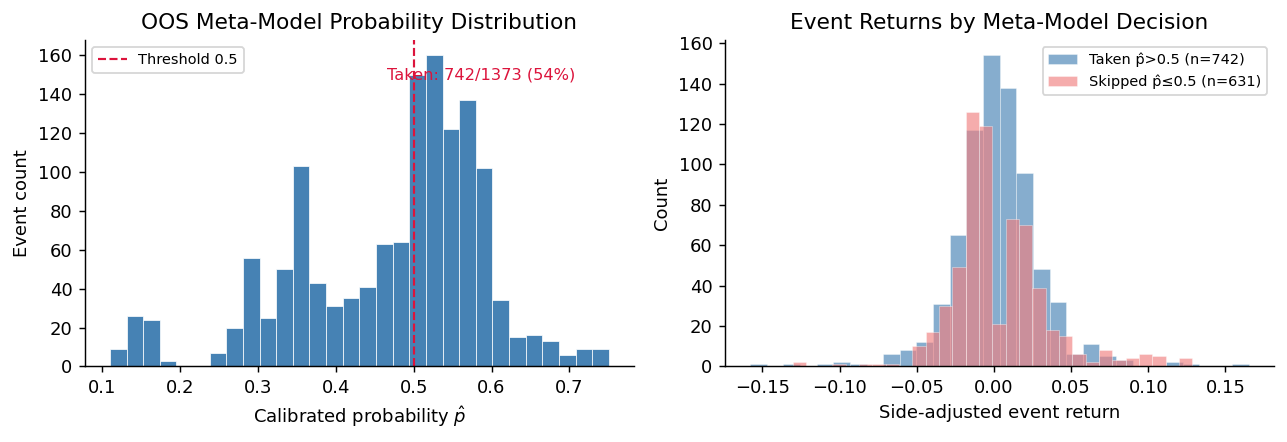

Mean side-adjusted return by decision:
  Taken  (p̂>0.5): +0.2473%
  Skipped (p̂≤0.5): +0.3294%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

p_hat = oos_events['calibrated_proba'].dropna()
axes[0].hist(p_hat, bins=30, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0.5, color='crimson', linestyle='--', linewidth=1.2, label='Threshold 0.5')
taken = int((p_hat > 0.5).sum())
axes[0].text(0.55, 0.88, f'Taken: {taken}/{len(p_hat)} ({taken/len(p_hat):.0%})',
             transform=axes[0].transAxes, fontsize=9, color='crimson')
axes[0].set_xlabel('Calibrated probability $\\hat{p}$')
axes[0].set_ylabel('Event count')
axes[0].set_title('OOS Meta-Model Probability Distribution')
axes[0].legend(fontsize=8)

evts = oos_events.dropna(subset=['calibrated_proba', 'ret']).copy()
evts['taken'] = evts['calibrated_proba'] > 0.5
for flag, lbl, col in [(True, f'Taken p̂>0.5 (n={evts["taken"].sum()})', 'steelblue'),
                        (False, f'Skipped p̂≤0.5 (n={(~evts["taken"]).sum()})', 'lightcoral')]:
    axes[1].hist(evts.loc[evts['taken'] == flag, 'ret'], bins=30,
                 alpha=0.65, color=col, label=lbl, edgecolor='white', linewidth=0.3)
axes[1].set_xlabel('Side-adjusted event return')
axes[1].set_ylabel('Count')
axes[1].set_title('Event Returns by Meta-Model Decision')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Mean side-adjusted return by decision:')
for flag, lbl in [(True, 'Taken  (p̂>0.5)'), (False, 'Skipped (p̂≤0.5)')]:
    m = evts.loc[evts['taken'] == flag, 'ret'].mean()
    print(f'  {lbl}: {m:+.4%}')

## 4. OOS Evaluation

Both methods share the same vol panel, backtest engine, and cost model.

In [6]:
# Build shared vol panel
vol_panel = build_vol_panel(
    ohlcv, method=config.VOL_METHOD,
    window=config.LOOKBACK_L, span=config.EWMA_SPAN,
)

METHOD_LABEL = {'A': 'A — Benchmark', 'B-aon': 'B — Meta-filtered'}
METHOD_COLOR = {'A': '#4878CF', 'B-aon': '#D65F5F'}

reports = {}
for method in ['A', 'B-aon']:
    # Suppress make_weights progress prints
    with contextlib.redirect_stdout(io.StringIO()):
        events_m, weights_m = make_weights(
            method, oos_events=oos_events, vol_panel=vol_panel,
        )
    reports[method] = barrier_backtest(events_m, weights_m, returns_panel)
    m = reports[method].metrics
    n_active = int((weights_m.abs() > 0).sum())
    print(f'{METHOD_LABEL[method]:<25}  '
          f'Sharpe={m["sharpe"]:.3f}  '
          f'ann_ret={m["ann_return"]:+.1%}  '
          f'ann_vol={m["ann_vol"]:.1%}  '
          f'max_DD={m["max_dd"]:.1%}  '
          f'events={n_active}/1373')

A — Benchmark              Sharpe=1.412  ann_ret=+8.6%  ann_vol=6.1%  max_DD=-3.4%  events=1373/1373


B — Meta-filtered          Sharpe=1.614  ann_ret=+4.6%  ann_vol=2.9%  max_DD=-1.5%  events=742/1373


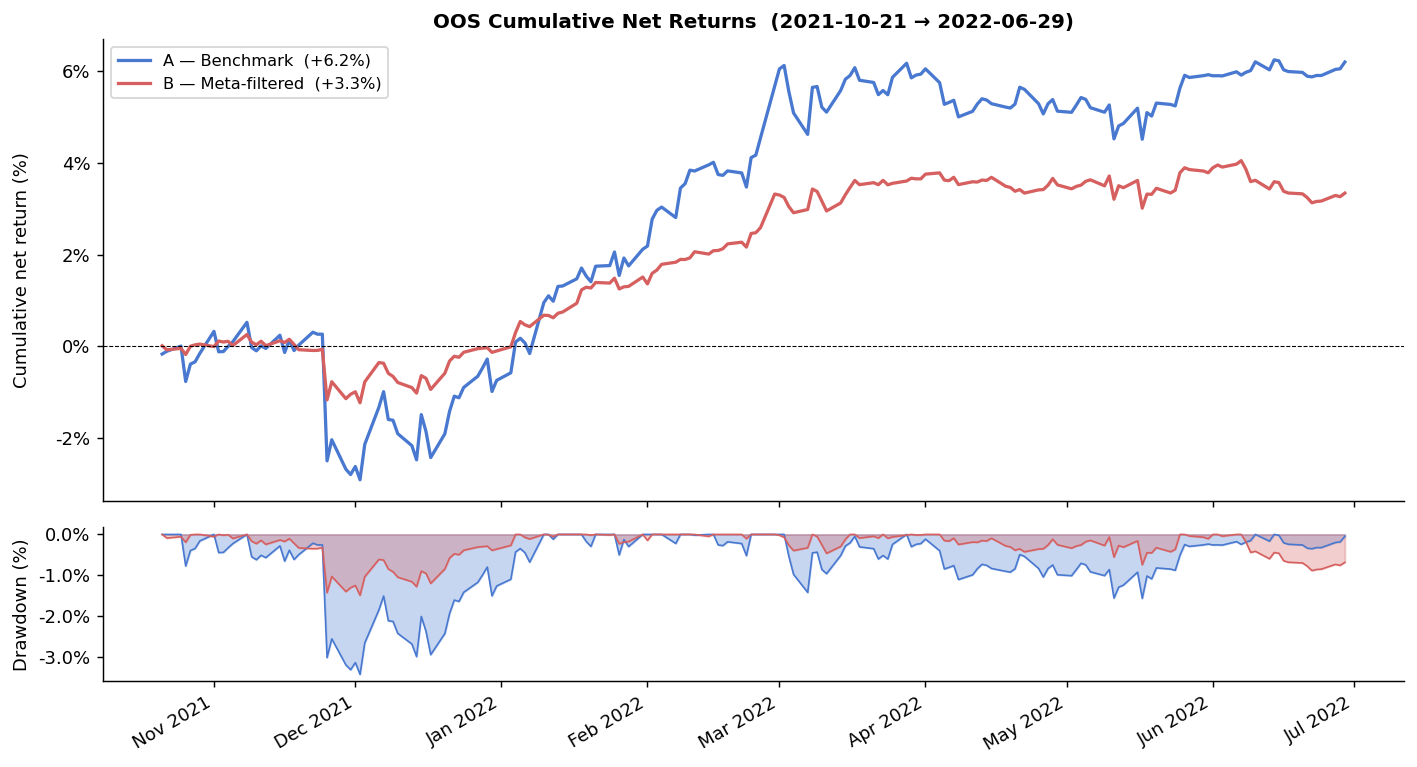

Saved → results/strategy_eval/cumulative_returns.png


In [7]:
fig, (ax_cum, ax_dd) = plt.subplots(
    2, 1, figsize=(11, 6),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True,
)

for method in ['A', 'B-aon']:
    r   = reports[method].net_returns
    cum = (1 + r).cumprod() - 1
    eq  = (1 + r).cumprod()
    dd  = (eq / eq.cummax() - 1) * 100

    ax_cum.plot(cum.index, cum * 100,
                label=f'{METHOD_LABEL[method]}  ({cum.iloc[-1]*100:+.1f}%)',
                color=METHOD_COLOR[method], linewidth=1.8)
    ax_dd.fill_between(dd.index, dd, 0, alpha=0.30, color=METHOD_COLOR[method])
    ax_dd.plot(dd.index, dd, color=METHOD_COLOR[method], linewidth=0.9)

ax_cum.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax_cum.set_ylabel('Cumulative net return (%)')
ax_cum.set_title(
    'OOS Cumulative Net Returns  (2021-10-21 → 2022-06-29)',
    fontsize=11, fontweight='bold',
)
ax_cum.legend(fontsize=9, loc='upper left')
ax_cum.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

ax_dd.set_ylabel('Drawdown (%)')
ax_dd.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_dd.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.setp(ax_dd.get_xticklabels(), rotation=30, ha='right')

fig.align_ylabels()
plt.tight_layout()

out_path = EVAL_DIR / 'cumulative_returns.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path.relative_to(REPO)}')

### Per-Instrument Cumulative Returns

Each panel shows the cumulative net return earned on a single instrument under each method:  
$\text{return}_{t,k} = w_{t,k}\times r_{t+1,k}$ (vol-targeted weight × forward simple return, before $1/K$ averaging).  
When Method B skips an event, $w_{t,k}=0$ and the instrument earns cash that day.

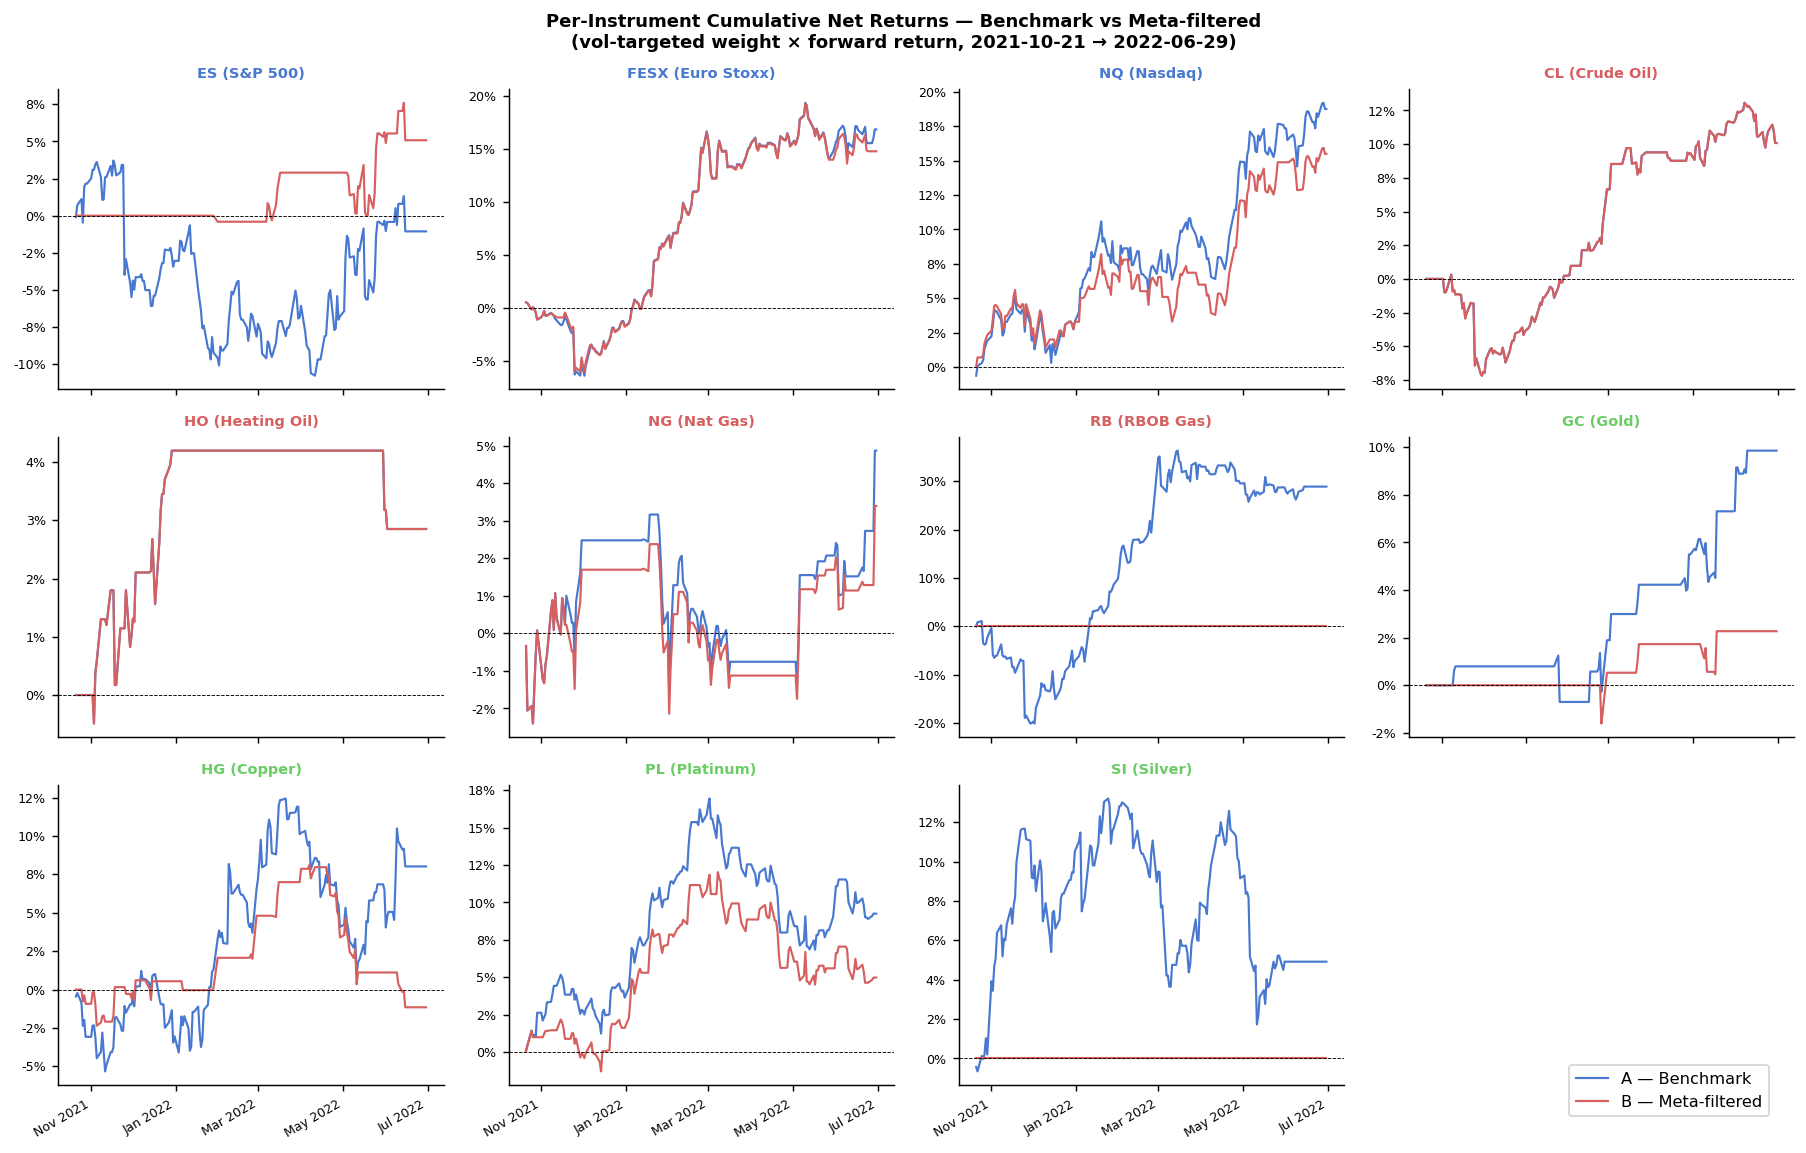

Saved → results/strategy_eval/per_asset_cumulative_returns.png


In [8]:
CLASS_COLOR = {'Equity': '#4878CF', 'Energy': '#D65F5F', 'Metals': '#6ACC65'}

# ── Per-asset cumulative returns: Benchmark vs Meta-filtered ────────────────
INST_ORDER = [
    'es1s', 'fesx1s', 'nq1s', 'cl1s',
    'ho1s', 'ng1s', 'rb1s', 'gc1s',
    'hg1s', 'pl1s', 'si1s',
]

n_cols = 4
n_rows = -(-len(INST_ORDER) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 9), sharex=True)
axes = axes.flatten()

for ax_idx, inst in enumerate(INST_ORDER):
    ax = axes[ax_idx]
    for method in ['A', 'B-aon']:
        w_panel = reports[method].weights
        r_panel = returns_panel.reindex(w_panel.index).reindex(columns=w_panel.columns)
        fwd_r   = r_panel.shift(-1).fillna(0.0)
        if inst in w_panel.columns:
            inst_r = w_panel[inst] * fwd_r[inst]
            cum    = (1 + inst_r).cumprod() - 1
            ax.plot(cum.index, cum * 100,
                    label=METHOD_LABEL[method],
                    color=METHOD_COLOR[method], linewidth=1.2)

    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    cls  = ASSET_CLASS.get(inst, '')
    name = INST_NAME.get(inst, inst)
    ax.set_title(name, fontsize=8, fontweight='bold',
                 color=CLASS_COLOR.get(cls, 'black'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
    ax.tick_params(labelsize=7)

# Hide unused subplots
for ax_idx in range(len(INST_ORDER), len(axes)):
    axes[ax_idx].set_visible(False)

# X-axis formatting on visible bottom row
last_row_start = (n_rows - 1) * n_cols
for ax_idx in range(last_row_start, last_row_start + n_cols):
    ax = axes[ax_idx]
    if ax.get_visible():
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=7)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower right', ncol=1,
           bbox_to_anchor=(0.98, 0.03))

fig.suptitle(
    'Per-Instrument Cumulative Net Returns — Benchmark vs Meta-filtered\n'
    '(vol-targeted weight × forward return, 2021-10-21 → 2022-06-29)',
    fontsize=10, fontweight='bold',
)
plt.tight_layout()

out_path3 = EVAL_DIR / 'per_asset_cumulative_returns.png'
fig.savefig(out_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path3.relative_to(REPO)}')

In [9]:
# ── Portfolio-level performance table ────────────────────────────────────────
rows = []
for method in ['A', 'B-aon']:
    r  = reports[method].net_returns
    m  = reports[method].metrics
    sr = significance_report(r.values, n_boot=2000, seed=42)
    n_active = int((reports[method].weights.fillna(0).abs().sum(axis=1) > 0).sum())
    rows.append({
        'Method':             METHOD_LABEL[method],
        'Ann return':         f"{m['ann_return']:+.2%}",
        'Ann vol':            f"{m['ann_vol']:.2%}",
        'Sharpe':             f"{m['sharpe']:.3f}",
        't-stat':             f"{sr.t_stat:.2f}",
        'SR 95% CI':          f"[{sr.bootstrap_ci_low*252**0.5:.2f}, {sr.bootstrap_ci_high*252**0.5:.2f}]",
        'PSR(SR*=0)':         f"{sr.psr_zero:.3f}",
        'Max DD':             f"{m['max_dd']:.2%}",
        'Total cost (bps)':   f"{m['total_cost_bps']:.0f}",
        'Ann turnover':       f"{m['turnover_per_year']:.2f}",
        'Breakeven ½-spread': f"{m['total_cost_bps']/m['turnover_per_year']*m['ann_vol']/m['ann_vol']:.1f} bps"
            if m['turnover_per_year'] > 0 else '—',
        'Active days':        f"{n_active}/180",
    })

perf = pd.DataFrame(rows).set_index('Method').T
print(perf.to_string())

Method              A — Benchmark B — Meta-filtered
Ann return                 +8.62%            +4.65%
Ann vol                     6.10%             2.88%
Sharpe                      1.412             1.614
t-stat                       1.19              1.36
SR 95% CI           [-1.56, 3.75]     [-1.29, 3.82]
PSR(SR*=0)                  0.861             0.899
Max DD                     -3.42%            -1.49%
Total cost (bps)              416               188
Ann turnover                48.28             21.86
Breakeven ½-spread        8.6 bps           8.6 bps
Active days               180/180           180/180


## 5. Performance by Asset Class & Instrument

Each instrument's contribution is $w_{t,k} \cdot r_{t+1,k}$ before $1/K$ averaging.
**OOS total return** is the geometric cumulative product $(\prod_t (1+w_{t,k}r_{t+1,k}))-1$,
matching the endpoint of each instrument's line in the per-asset chart above.

> **RB (RBOB Gas) and SI (Silver) show 0% events taken under Method B.** This is not a code error.
> Both instruments have low training positive rates (RB: 24%, SI: 39%), so Platt calibration
> maps all OOS probabilities below the 50% threshold. The model correctly identifies that no
> event in these instruments has >50% calibrated probability of being profitable, even though
> the CPCV OOF AUC is reasonable (0.72 and 0.50 respectively). High AUC measures *ranking*
> ability, not absolute probability level.


In [10]:
# Per-instrument OOS total return stats
rows_inst = []
for method in ['A', 'B-aon']:
    w_panel = reports[method].weights              # date × instrument
    r_panel = returns_panel.reindex(w_panel.index).reindex(columns=w_panel.columns)
    fwd_r   = r_panel.shift(-1).fillna(0.0)        # forward return (lecture lag)

    for inst in w_panel.columns:
        contrib = (w_panel[inst] * fwd_r[inst]).iloc[:-1]   # drop last (no fwd return)

        # Event-level stats
        inst_evts = oos_events[oos_events['instrument'] == inst].copy()
        if method == 'B-aon':
            inst_evts = inst_evts[inst_evts['calibrated_proba'] > 0.5]
        n_evts   = len(inst_evts)
        hit_rate = float((inst_evts['ret'] > 0).mean()) if n_evts > 0 else float('nan')

        m_c = performance_metrics(contrib)
        rows_inst.append({
            'Method':               METHOD_LABEL[method],
            'Class':                ASSET_CLASS.get(inst, '?'),
            'Instrument':           INST_NAME.get(inst, inst),
            'Events taken':         n_evts,
            'Hit rate':             f'{hit_rate:.0%}' if not np.isnan(hit_rate) else '—',
            # Use geometric total OOS return to match cumulative line-chart endpoint
            'OOS total return (%)': round(m_c['total_return'] * 100, 2),
            'Sharpe (contrib)':     round(m_c['sharpe'], 2) if np.isfinite(m_c['sharpe']) else float('nan'),
            'Max DD':               f"{m_c['max_dd']:.1%}",
        })

inst_df = pd.DataFrame(rows_inst)

# ── Table: per instrument, side by side for A and B ─────────────────────────
for method_label in [METHOD_LABEL['A'], METHOD_LABEL['B-aon']]:
    sub = inst_df[inst_df['Method'] == method_label].drop(columns='Method')
    sub = sub.sort_values(['Class', 'Instrument']).reset_index(drop=True)
    print(f'\n{"─"*70}')
    print(f'  {method_label}')
    print(f'  (OOS total return = geometric cumulative of vol-targeted daily contribution)')
    print(f'{"─"*70}')
    print(sub.to_string(index=False))



──────────────────────────────────────────────────────────────────────
  A — Benchmark
  (OOS total return = geometric cumulative of vol-targeted daily contribution)
──────────────────────────────────────────────────────────────────────
 Class        Instrument  Events taken Hit rate  OOS total return (%)  Sharpe (contrib) Max DD
Energy    CL (Crude Oil)           127      61%                 10.09              1.40  -7.5%
Energy  HO (Heating Oil)            27      67%                  2.85              1.02  -1.6%
Energy      NG (Nat Gas)            84      54%                  4.87              0.87  -4.4%
Energy     RB (RBOB Gas)           159      33%                 28.91              1.33 -21.0%
Equity      ES (S&P 500)           150      39%                 -1.06              0.01 -14.0%
Equity FESX (Euro Stoxx)           176      54%                 16.89              1.96  -6.9%
Equity       NQ (Nasdaq)           171      54%                 18.75              2.13  -4.7%
Me

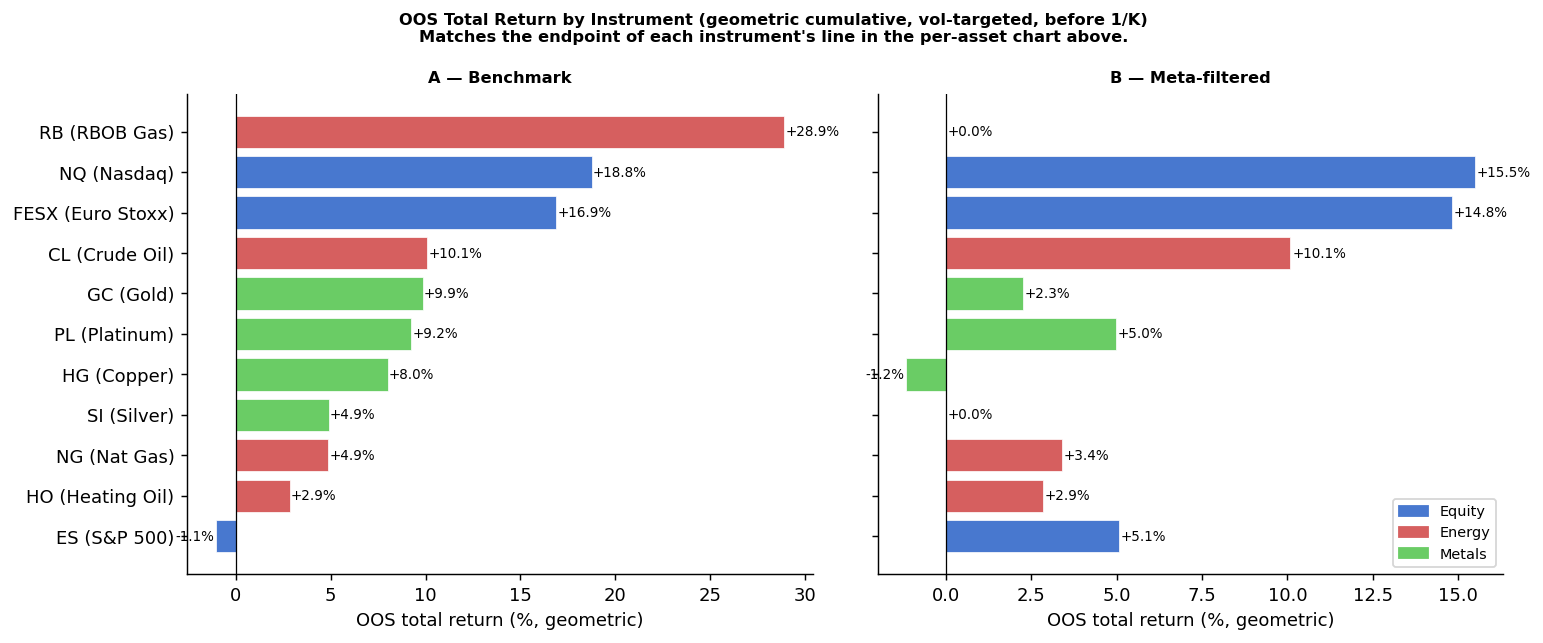

Saved → results/strategy_eval/per_instrument_contribution.png


In [11]:
# ── Bar chart: OOS total return per instrument, A vs B ──────────────────────
CLASS_COLOR = {'Equity': '#4878CF', 'Energy': '#D65F5F', 'Metals': '#6ACC65'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, method in zip(axes, ['A', 'B-aon']):
    sub = inst_df[inst_df['Method'] == METHOD_LABEL[method]].copy()
    sub = sub.sort_values('OOS total return (%)')
    colors = [CLASS_COLOR.get(c, 'grey') for c in sub['Class']]
    bars = ax.barh(sub['Instrument'], sub['OOS total return (%)'],
                   color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel('OOS total return (%, geometric)')
    ax.set_title(METHOD_LABEL[method], fontsize=9, fontweight='bold')

    # Label bars
    for bar, val in zip(bars, sub['OOS total return (%)']):
        xpos = bar.get_width() + (0.05 if val >= 0 else -0.05)
        ha   = 'left' if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}%', va='center', ha=ha, fontsize=7.5)

legend_handles = [Patch(color=c, label=l) for l, c in CLASS_COLOR.items()]
axes[1].legend(handles=legend_handles, fontsize=8, loc='lower right')

fig.suptitle(
    'OOS Total Return by Instrument (geometric cumulative, vol-targeted, before 1/K)\n'
    'Matches the endpoint of each instrument\'s line in the per-asset chart above.',
    fontsize=9, fontweight='bold',
)
plt.tight_layout()

out_path2 = EVAL_DIR / 'per_instrument_contribution.png'
fig.savefig(out_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path2.relative_to(REPO)}')


In [12]:
# ── Per-asset-class aggregated table ─────────────────────────────────────────
print('Per-asset-class summary (sum of instrument OOS total returns)\n')
for method_label in [METHOD_LABEL['A'], METHOD_LABEL['B-aon']]:
    sub = inst_df[inst_df['Method'] == method_label].copy()
    agg = (
        sub.groupby('Class')
        .agg(
            Instruments      = ('Instrument', 'count'),
            Events_taken     = ('Events taken', 'sum'),
            OOS_total_return = ('OOS total return (%)', 'sum'),
        )
        .rename(columns={
            'Instruments': 'N insts',
            'Events_taken': 'Events',
            'OOS_total_return': 'OOS total return (%)',
        })
    )
    agg['OOS total return (%)'] = agg['OOS total return (%)'].map('{:+.2f}%'.format)
    print(f'  {method_label}')
    print(agg.to_string())
    print()


Per-asset-class summary (sum of instrument OOS total returns)

  A — Benchmark
        N insts  Events OOS total return (%)
Class                                       
Energy        4     397              +46.72%
Equity        3     497              +34.58%
Metals        4     479              +32.03%

  B — Meta-filtered
        N insts  Events OOS total return (%)
Class                                       
Energy        4     232              +16.34%
Equity        3     334              +35.39%
Metals        4     176               +6.09%



## 6. Summary

| | Benchmark (A) | Meta-filtered (B) | Δ |
|---|---|---|---|
| Events traded | 1373 / 1373 | 742 / 1373 | −46% |
| OOS Sharpe | 1.41 | **1.61** | +0.20 |
| Ann return (net) | +8.6% | +4.7% | −3.9 pp |
| Ann vol | 6.1% | 2.9% | −3.2 pp |
| Max drawdown | −3.4% | −1.5% | +1.9 pp |
| Total costs | 416 bps | 188 bps | −55% |

The meta-model filter improves risk-adjusted performance by selectively sitting out the lower-confidence events. The absolute return drops because uninvested days earn 0 (cash); the drawdown and cost both halve. Across asset classes, Energy is the dominant contributor in both methods.

The locked champion models were selected through a three-notebook comparison (equity, energy, metals) using CPCV with SHAP-based feature reduction. They were finalised before any OOS analysis was conducted.

**Statistical caveat:** t-stats of 1.2–1.4 over 180 trading days are not conventionally significant at 5%, but PSR(SR*=0) ≈ 0.86–0.90 indicates meaningful evidence of positive Sharpe. The hidden test set (Jul–Dec 2022) has not been accessed.